# Fraud Detection - Random Forest

This notebook extends the fraud detection analysis by evaluating a Random Forest classifier as an alternative to the Logistic Regression baseline.

The Logistic Regression model developed in the previous notebook showed poor fraud detection performance despite feature scaling and classification threshold analysis. This suggests that the problem cannot be resolved simply by improving model convergence or changing the decision threshold.

Random Forest is introduced as a more flexible, non-linear model capable of capturing interactions and patterns that Logistic Regression may not represent effectively.

The main goals are to:
- prepare the fraud dataset for Random Forest modeling,
- train and evaluate a Random Forest classifier,
- analyze its fraud detection performance using recall, precision and F1-score,
- compare its performance with the previous Logistic Regression baseline,
- determine whether a more flexible model provides better separation between fraudulent and non-fraudulent transactions.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
)

from finsight.database import (
    connect_to_database,
    test_database_connection,
)

from finsight.fraud_data import (
    download_train_data,
    download_validation_data,
)

from finsight.fraud_preprocessing import (
    encode_categorical_features,
    handle_missing_values,
)

from finsight.validation import (
    check_missing_values
)

In [38]:
engine = connect_to_database()
test_database_connection(engine)

Connected!


In [39]:
X_train, y_train = download_train_data(engine)
X_val, y_val = download_validation_data(engine)

In [40]:
final_train, final_val = encode_categorical_features(X_train, X_val)
final_train, final_val = handle_missing_values(final_train, final_val)

In [41]:
check_missing_values(final_train)

amount                             0
mcc_key                            0
merchant_id                        0
transaction_hour                   0
day_of_week                        0
is_weekend                         0
user_previous_transaction_count    0
user_previous_avg_amount           0
amount_vs_user_avg                 0
card_previous_transaction_count    0
card_previous_avg_amount           0
amount_vs_card_avg                 0
use_chip_Chip Transaction          0
use_chip_Online Transaction        0
use_chip_Swipe Transaction         0
dtype: int64

In [42]:
check_missing_values(final_val)

amount                             0
mcc_key                            0
merchant_id                        0
transaction_hour                   0
day_of_week                        0
is_weekend                         0
user_previous_transaction_count    0
user_previous_avg_amount           0
amount_vs_user_avg                 0
card_previous_transaction_count    0
card_previous_avg_amount           0
amount_vs_card_avg                 0
use_chip_Chip Transaction          0
use_chip_Online Transaction        0
use_chip_Swipe Transaction         0
dtype: int64

## Baseline Random Forest Model

In [43]:
rf = RandomForestClassifier(random_state=42)
rf.fit(final_train, y_train)
print("Training set score: {:.4f}".format(rf.score(final_train, y_train)))
print("Validation set score: {:.4f}".format(rf.score(final_val, y_val)))

Training set score: 1.0000
Validation set score: 0.9974


In [44]:
y_pred = rf.predict(final_val)
y_pred.sum()

np.int64(947)

### Performance Metrics

In [45]:
recall = recall_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
print("Recall: {:.4f}".format(recall))
print("Precision: {:.4f}".format(precision))
print("F1: {:.4f}".format(f1))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Recall: 0.0411
Precision: 0.0707
F1: 0.0520
Confusion Matrix:
[[932090    880]
 [  1562     67]]


## Random Forest with Limited Tree Depth

The baseline Random Forest fits the training data almost perfectly, while its fraud detection performance on the validation set remains poor.

To investigate whether reducing model complexity improves generalization, two Random Forest models are evaluated with `max_depth=10` and `max_depth=20`.

The models are compared with the baseline using recall, precision and F1-score.

In [46]:
rf_limited10 = RandomForestClassifier(max_depth=10, random_state=42)
rf_limited10.fit(final_train, y_train)
print("Training set score: {:.4f}".format(rf_limited10.score(final_train, y_train)))
print("Validation set score: {:.4f}".format(rf_limited10.score(final_val, y_val)))

Training set score: 0.9835
Validation set score: 0.9976


In [47]:
y_pred_limited = rf_limited10.predict(final_val)

In [48]:
recall_limited10 = recall_score(y_val, y_pred_limited)
precision_limited10 = precision_score(y_val, y_pred_limited)
f1_limited10 = f1_score(y_val, y_pred_limited)
print("Recall: {:.4f}".format(recall_limited10))
print("Precision: {:.4f}".format(precision_limited10))
print("F1: {:.4f}".format(f1_limited10))

Recall: 0.0289
Precision: 0.0623
F1: 0.0394


In [49]:
rf_limited20 = RandomForestClassifier(max_depth=20, random_state=42)
rf_limited20.fit(final_train, y_train)
print("Training set score: {:.4f}".format(rf_limited20.score(final_train, y_train)))
print("Validation set score: {:.4f}".format(rf_limited20.score(final_val, y_val)))

Training set score: 0.9964
Validation set score: 0.9974


In [50]:
y_pred_limited20 = rf_limited20.predict(final_val)

In [51]:
recall_limited20 = recall_score(y_val, y_pred_limited20)
precision_limited20 = precision_score(y_val, y_pred_limited20)
f1_limited20 = f1_score(y_val, y_pred_limited20)
print("Recall: {:.4f}".format(recall_limited20))
print("Precision: {:.4f}".format(precision_limited20))
print("F1: {:.4f}".format(f1_limited20))

Recall: 0.0405
Precision: 0.0714
F1: 0.0517


In [52]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "max_depth=10",
        "max_depth=20"
    ],
    "Recall": [
        recall,
        recall_limited10,
        recall_limited20
    ],
    "Precision": [
        precision,
        precision_limited10,
        precision_limited20
    ],
    "F1": [
        f1,
        f1_limited10,
        f1_limited20
    ]
})

results = pd.DataFrame(results).set_index("Model")
results

,Recall,Precision,F1
Model,,,
Baseline,0.041130,0.070750,0.052019
max_depth=10,0.028852,0.062334,0.039446
max_depth=20,0.040516,0.071351,0.051684


### Comparison Summary

Limiting the maximum tree depth reduced the model's ability to fit the training data, but did not improve fraud detection on the validation set.

- `max_depth=10` produced the weakest recall, precision and F1-score.
- `max_depth=20` performed better than `max_depth=10`, but still did not outperform the baseline Random Forest.
- The baseline model without a depth limit achieved the highest recall, precision and F1-score.

These results suggest that limiting tree depth alone does not improve the model's ability to detect fraudulent transactions.

Since fraud represents a minority class, the next experiment investigates whether assigning greater importance to fraudulent observations during training can improve detection performance.

## Random Forest with Class Weighting

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of observations.

To investigate whether the model can become more sensitive to fraud, a Random Forest with `class_weight="balanced"` is evaluated. This automatically assigns greater weight to the minority class during training.

All other model parameters remain unchanged to isolate the effect of class weighting.## Random Forest with Class Weighting

In [53]:
rf_balanced = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_balanced.fit(final_train, y_train)
print("Training set score: {:.4f}".format(rf_balanced.score(final_train, y_train)))
print("Validation set score: {:.4f}".format(rf_balanced.score(final_val, y_val)))

Training set score: 0.9997
Validation set score: 0.9959


In [54]:
y_pred_balanced = rf_balanced.predict(final_val)

In [55]:
recall_balanced = recall_score(y_val, y_pred_balanced)
precision_balanced = precision_score(y_val, y_pred_balanced)
f1_balanced = f1_score(y_val, y_pred_balanced)
print("Recall: {:.4f}".format(recall_balanced))
print("Precision: {:.4f}".format(precision_balanced))
print("F1: {:.4f}".format(f1_balanced))

Recall: 0.0424
Precision: 0.0295
F1: 0.0348


In [56]:
print(confusion_matrix(y_val, y_pred_balanced))

[[930701   2269]
 [  1560     69]]


### Class Weighting Results

Using `class_weight="balanced"` slightly increased fraud recall, but substantially reduced precision and F1-score.

The weighted model detected only 3 additional fraudulent transactions compared with the baseline, while producing 1,314 additional false positives.

This suggests that class weighting makes the model more willing to predict fraud, but does not substantially improve its ability to distinguish fraudulent from legitimate transactions. Class weighting alone is therefore insufficient to address the poor fraud detection performance.

## Feature Importance Analysis

The previous experiments showed that changing model complexity and applying class weighting did not substantially improve fraud detection performance.

This suggests that the main limitation may not be the Random Forest configuration itself, but the predictive information available in the current feature set.

To better understand how the model makes its decisions, feature importance will be analyzed for the baseline Random Forest. The goal is to identify which features contribute most strongly to the model and whether the current feature set provides meaningful signals for distinguishing fraudulent from legitimate transactions.

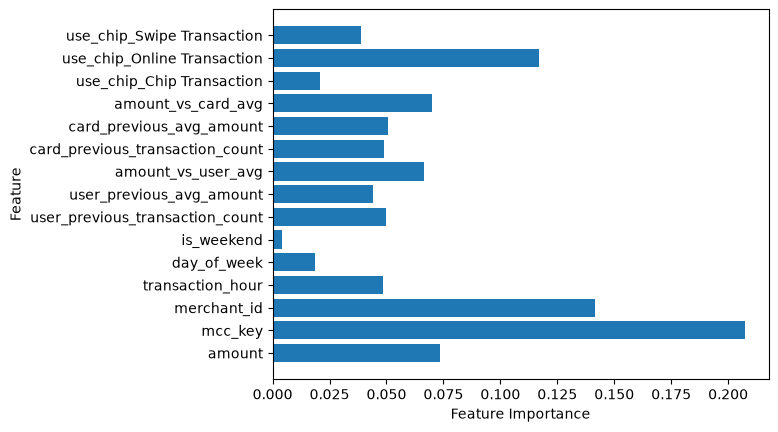

In [57]:
def plot_feature_importances(model):
    n_features = final_train.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align="center")
    plt.yticks(np.arange(n_features), final_train.columns.tolist())
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

plot_feature_importances(rf)

### Feature Importance Findings

The baseline Random Forest relies most strongly on transaction method and merchant-related features. `use_chip_Online Transaction` has the highest feature importance, while `mcc_key` is also among the most influential features.

However, `mcc_key` represents a merchant category rather than an ordered numerical quantity. Treating it as a continuous numerical feature allows the trees to create threshold-based splits between arbitrary category identifiers.

The next experiment therefore investigates whether representing `mcc_key` as a categorical feature using one-hot encoding improves fraud detection.

## Categorical MCC Encoding

In [58]:
X_train_mcc = X_train.copy()
X_val_mcc = X_val.copy()

X_train_mcc["mcc_key"] = X_train_mcc["mcc_key"].astype(str)
X_val_mcc["mcc_key"] = X_val_mcc["mcc_key"].astype(str)

In [59]:
final_train_mcc, final_val_mcc = encode_categorical_features(X_train_mcc, X_val_mcc)

In [60]:
check_missing_values(final_train_mcc)[check_missing_values(final_train_mcc)>0]

user_previous_avg_amount    30
amount_vs_user_avg          30
card_previous_avg_amount    93
amount_vs_card_avg          93
dtype: int64

In [61]:
final_train_mcc, final_val_mcc = handle_missing_values(final_train_mcc, final_val_mcc)

In [62]:
rf_mcc = RandomForestClassifier(random_state=42)
rf_mcc.fit(final_train_mcc, y_train)
print("Training set score: {:.4f}".format(rf_mcc.score(final_train_mcc, y_train)))
print("Validation set score: {:.4f}".format(rf_mcc.score(final_val_mcc, y_val)))

Training set score: 1.0000
Validation set score: 0.9976


In [63]:
y_pred_mcc = rf_mcc.predict(final_val_mcc)

In [64]:
recall_mcc = recall_score(y_val, y_pred_mcc)
precision_mcc = precision_score(y_val, y_pred_mcc)
f1_mcc = f1_score(y_val, y_pred_mcc)
print("Recall: {:.4f}".format(recall_mcc))
print("Precision: {:.4f}".format(precision_mcc))
print("F1: {:.4f}".format(f1_mcc))

Recall: 0.0577
Precision: 0.1137
F1: 0.0765


### MCC Encoding Experiment Results

Treating `mcc_key` as a categorical feature improved the Random Forest fraud detection performance compared with the baseline model.

The categorical MCC model achieved:
- recall: 0.0559
- precision: 0.1117
- F1-score: 0.0745

All three fraud detection metrics improved compared with the baseline Random Forest.

This suggests that the representation of categorical variables matters for model performance. Although `mcc_key` was originally stored as a numerical identifier, its values represent categories rather than an ordered numerical quantity. One-hot encoding therefore provides a more appropriate representation for the model.

Despite the improvement, recall remains very low, indicating that the current model still fails to identify most fraudulent transactions. Further investigation of the feature set is therefore required.

In [65]:
final_train["merchant_id"].value_counts(dropna=False)

merchant_id
27092    14124
59935    13875
61195    12739
39021     9805
43293     8421
         ...  
54134        1
93546        1
35519        1
96590        1
34234        1
Name: count, Length: 18767, dtype: int64

## Model Without Merchant ID

In [66]:
final_train_mcc_merchant = final_train_mcc.drop(columns="merchant_id")
final_val_mcc_merchant = final_val_mcc.drop(columns="merchant_id")

In [67]:
final_train_mcc_merchant.shape

(310343, 122)

In [ ]:
rf_mcc_merchant = RandomForestClassifier(random_state=42)
rf_mcc_merchant.fit(final_train_mcc_merchant, y_train)
print("Training set score: {:.4f}".format(rf_mcc_merchant.score(final_train_mcc_merchant, y_train)))
print("Validation set score: {:.4f}".format(rf_mcc_merchant.score(final_val_mcc_merchant, y_val)))

Training set score: 1.0000


In [ ]:
y_pred_mcc_merchant = rf_mcc_merchant.predict(final_val_mcc_merchant)

In [ ]:
recall_mcc_merchant = recall_score(y_val, y_pred_mcc_merchant)
precision_mcc_merchant  = precision_score(y_val, y_pred_mcc_merchant)
f1_mcc_merchant  = f1_score(y_val, y_pred_mcc_merchant)
print("Recall: {:.4f}".format(recall_mcc_merchant))
print("Precision: {:.4f}".format(precision_mcc_merchant))
print("F1: {:.4f}".format(f1_mcc_merchant))

### Merchant ID Removal Experiment Results

Removing `merchant_id` did not improve the Random Forest model.

Compared with the categorical MCC model, recall decreased from 0.0559 to 0.0510, precision from 0.1117 to 0.0666, and F1-score from 0.0745 to 0.0577.

This suggests that `merchant_id` contains useful predictive information despite being represented as a numerical identifier. Removing the feature therefore results in a loss of information.

For this reason, `merchant_id` is retained in the current model. However, its high cardinality makes simple one-hot encoding impractical, so its representation remains a potential area for future improvement.